In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory



# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
! pip install wfdb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import ast

import wfdb

from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

2026-04-21 04:25:36.477321: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776745536.903648      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776745537.002304      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
PATH_TO_DATA = '/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/'

#CSV files
ECG_df = pd.read_csv(os.path.join(PATH_TO_DATA, 'ptbxl_database.csv'), index_col='ecg_id')
SCP_df = pd.read_csv(os.path.join(PATH_TO_DATA, 'scp_statements.csv'), index_col=0)


#The result of this line of code is that each element in the 'scp_codes' column of the DataFrame Y is evaluated using ast.literal_eval(),
#effectively converting string representations of Python literals (e.g., lists or dictionaries) into their corresponding Python objects.
ECG_df.scp_codes = ECG_df.scp_codes.apply(lambda x: ast.literal_eval(x))
ECG_df.patient_id = ECG_df.patient_id.astype(int)
ECG_df.nurse = ECG_df.nurse.astype('Int64')
ECG_df.site = ECG_df.site.astype('Int64')
ECG_df.validated_by = ECG_df.validated_by.astype('Int64')



#filters the DataFrame SCP_df to select only those rows where the value in the column 'diagnostic' is equal to 1.
SCP_df = SCP_df[SCP_df.diagnostic == 1]

In [5]:
agg_csv =ECG_df.copy()

In [6]:
#heart sound signal data file i.e. X is created

def load_raw_data(df, sampling_rate, path):
    lead = []
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
        lead_name= [wfdb.rdheader(path+f) for f in df.filename_lr]
        for i in lead_name:
            lead.append(i.sig_name)
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
        lead_name= [wfdb.rdheader(path+f) for f in df.filename_lr]
        for i in lead_name:
            lead.append(i.sig_name)
    data = np.array([signal for signal, meta in data])
    return data,lead


sampling_rate=100
X,lead = load_raw_data(ECG_df, sampling_rate, PATH_TO_DATA)

In [7]:
X_reshaped = np.transpose(X, (0, 2, 1))
X_reshaped.shape

(21837, 12, 1000)

In [8]:
SCP_df1=SCP_df.copy()

In [9]:
def aggregate_diagnostic(agg_csv_dic):
    tmp = []
    for key in agg_csv_dic.keys():
        if key in SCP_df1.index:
            tmp.append(SCP_df1.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
agg_csv['diagnostic_superclass'] = agg_csv.scp_codes.apply(aggregate_diagnostic)

In [10]:
print(agg_csv.columns)


Index(['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site',
       'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr',
       'diagnostic_superclass'],
      dtype='object')


In [11]:
#agg_csv.diagnostic_superclass.value_counts()
agg_csv['diagnostic_superclass'] = agg_csv['diagnostic_superclass'].apply(tuple)
counts = agg_csv['diagnostic_superclass'].value_counts()
print(counts)


diagnostic_superclass
(NORM,)                9083
(MI,)                  2538
(STTC,)                2406
(CD,)                  1709
(MI, CD)               1302
(STTC, HYP)             610
(MI, STTC)              602
(HYP,)                  536
(STTC, CD)              472
(NORM, CD)              407
()                      407
(STTC, MI, HYP)         340
(HYP, CD)               300
(MI, STTC, CD)          223
(MI, HYP)               183
(HYP, STTC)             173
(STTC, HYP, CD)         156
(STTC, MI, HYP, CD)     144
(MI, HYP, CD)           117
(HYP, STTC, CD)          55
(NORM, STTC)             28
(MI, HYP, STTC)          22
(MI, HYP, STTC, CD)      14
(NORM, STTC, CD)          5
(NORM, HYP, CD)           2
(NORM, HYP)               2
(NORM, MI, HYP, CD)       1
Name: count, dtype: int64


In [12]:
agg_csv_filter = agg_csv.copy()

In [13]:
agg_csv_filter['diagnostic_superclass'] = agg_csv_filter['diagnostic_superclass'].apply(lambda x: 'Other' if x == () else x)
agg_csv_filter.diagnostic_superclass.value_counts()


diagnostic_superclass
(NORM,)                9083
(MI,)                  2538
(STTC,)                2406
(CD,)                  1709
(MI, CD)               1302
(STTC, HYP)             610
(MI, STTC)              602
(HYP,)                  536
(STTC, CD)              472
(NORM, CD)              407
Other                   407
(STTC, MI, HYP)         340
(HYP, CD)               300
(MI, STTC, CD)          223
(MI, HYP)               183
(HYP, STTC)             173
(STTC, HYP, CD)         156
(STTC, MI, HYP, CD)     144
(MI, HYP, CD)           117
(HYP, STTC, CD)          55
(NORM, STTC)             28
(MI, HYP, STTC)          22
(MI, HYP, STTC, CD)      14
(NORM, STTC, CD)          5
(NORM, HYP, CD)           2
(NORM, HYP)               2
(NORM, MI, HYP, CD)       1
Name: count, dtype: int64

In [14]:
# Convert values to strings and then check unique values in 'diagnostic_superclass' column
print(agg_csv_filter['diagnostic_superclass'].astype(str).unique())

["('NORM',)" "('MI',)" 'Other' "('STTC',)" "('HYP',)" "('CD',)"
 "('MI', 'STTC')" "('HYP', 'CD')" "('MI', 'CD')" "('STTC', 'CD')"
 "('MI', 'HYP')" "('STTC', 'HYP')" "('MI', 'HYP', 'STTC')"
 "('STTC', 'MI', 'HYP', 'CD')" "('NORM', 'CD')" "('STTC', 'MI', 'HYP')"
 "('MI', 'STTC', 'CD')" "('HYP', 'STTC')" "('STTC', 'HYP', 'CD')"
 "('HYP', 'STTC', 'CD')" "('NORM', 'STTC')" "('MI', 'HYP', 'CD')"
 "('MI', 'HYP', 'STTC', 'CD')" "('NORM', 'STTC', 'CD')"
 "('NORM', 'HYP', 'CD')" "('NORM', 'HYP')" "('NORM', 'MI', 'HYP', 'CD')"]


In [15]:
Y_filtered =agg_csv_filter #csv data
X_filtered =X_reshaped  #Rhythm

In [16]:
# Continue to split data into train and test
test_fold = 10

# Train
X_train = X_filtered[np.where(Y_filtered.strat_fold != test_fold)] #where strat_fold is less than 10 will go foer training 
y_train = Y_filtered[(Y_filtered.strat_fold != test_fold)].diagnostic_superclass

# Test
X_test = X_filtered[np.where(Y_filtered.strat_fold == test_fold)]
y_test = Y_filtered[Y_filtered.strat_fold == test_fold].diagnostic_superclass

y_train = y_train.apply(lambda x: x[0])
y_test = y_test.apply(lambda x: x[0])#staring string is taken


In [17]:
X_train = X_train.transpose(0, 2, 1)
X_test = X_test.transpose(0, 2, 1)

In [18]:
print(y_train.head(10))  # Show the first 10 elements to understand the structure
print(y_train.dtypes)  # Check the data type of `y_train`


ecg_id
1     NORM
2     NORM
3     NORM
4     NORM
5     NORM
6     NORM
7     NORM
8       MI
10    NORM
11    NORM
Name: diagnostic_superclass, dtype: object
object


In [19]:
y_train.value_counts()

diagnostic_superclass
NORM    8564
MI      4503
STTC    3722
CD      1525
HYP      953
O        367
Name: count, dtype: int64

In [20]:
y_test.value_counts()

diagnostic_superclass
NORM    964
MI      498
STTC    406
CD      184
HYP     111
O        40
Name: count, dtype: int64

In [21]:
# Find the index of the record_name in Y_filtered
index = Y_filtered.index[0]
#[Y_filtered['filename_lr'] == record_name]
# Extract the signal from X_filtered based on the index
signal = X_filtered[index]

# Now you can print the signal
print(signal)

[[ 0.004 -0.02  -0.053 ...  0.121 -0.326 -0.348]
 [ 0.138  0.116  0.092 ...  0.398  0.057 -0.056]
 [ 0.134  0.136  0.145 ...  0.277  0.383  0.292]
 ...
 [ 0.192  0.156  0.107 ... -1.065 -0.28  -0.308]
 [ 0.083  0.057  0.013 ... -0.492 -0.175 -0.231]
 [ 0.088  0.063  0.022 ... -0.156 -0.071 -0.145]]


In [22]:
# Convert list to array
lead_array = np.array(lead)
print(lead_array)

[['I' 'II' 'III' ... 'V4' 'V5' 'V6']
 ['I' 'II' 'III' ... 'V4' 'V5' 'V6']
 ['I' 'II' 'III' ... 'V4' 'V5' 'V6']
 ...
 ['I' 'II' 'III' ... 'V4' 'V5' 'V6']
 ['I' 'II' 'III' ... 'V4' 'V5' 'V6']
 ['I' 'II' 'III' ... 'V4' 'V5' 'V6']]


In [23]:
one_lead = lead_array[0]
print(one_lead)

['I' 'II' 'III' 'AVR' 'AVL' 'AVF' 'V1' 'V2' 'V3' 'V4' 'V5' 'V6']


In [24]:
one_lead = lead_array[0]
formatted_lead = [[value] for value in one_lead]
print(formatted_lead)

[['I'], ['II'], ['III'], ['AVR'], ['AVL'], ['AVF'], ['V1'], ['V2'], ['V3'], ['V4'], ['V5'], ['V6']]


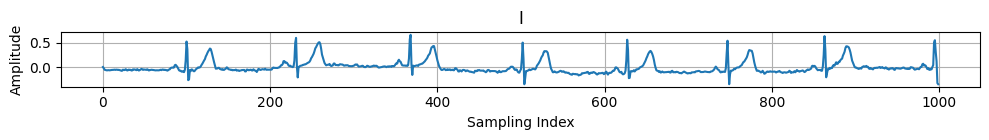

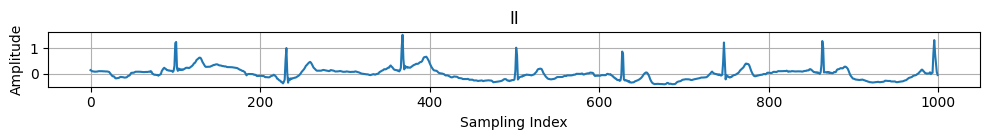

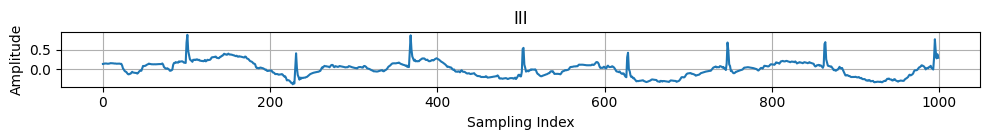

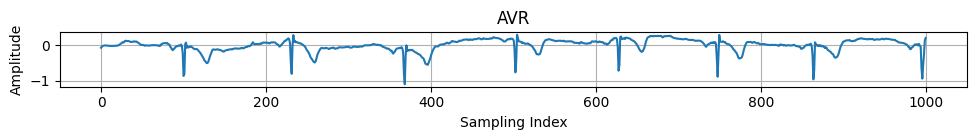

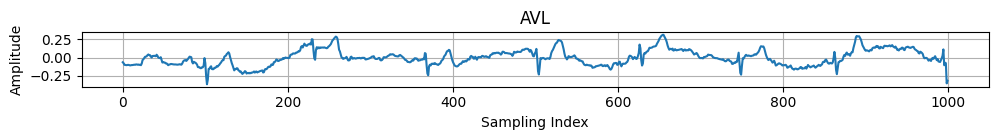

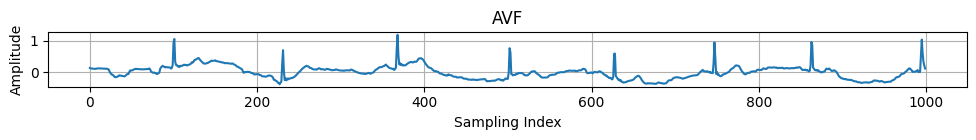

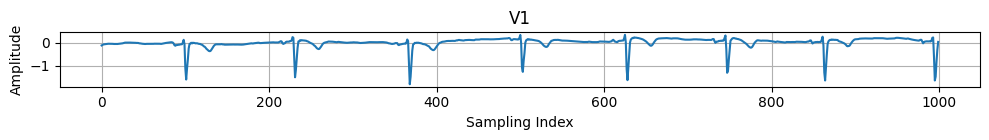

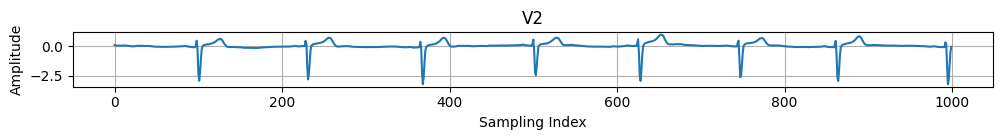

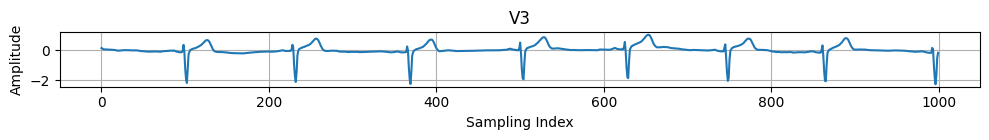

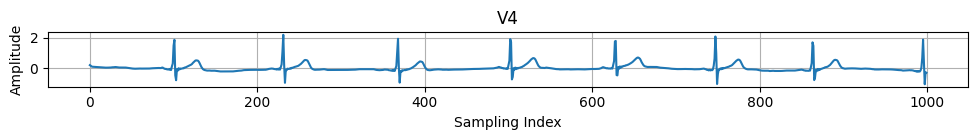

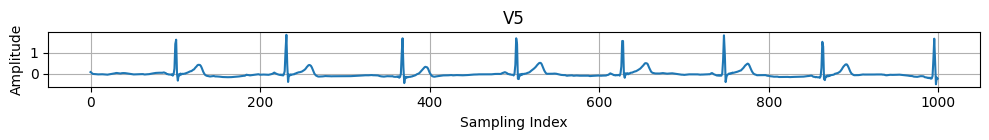

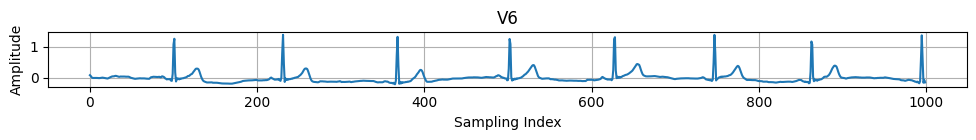

In [25]:
for row, label in zip(signal, formatted_lead):
    for j, lbl in enumerate(label):  # Unpack the index-value tuple
        plt.figure(figsize=(10, 1.5))  # Create a new figure for each plot
        plt.plot(row)
        plt.xlabel('Sampling Index')
        plt.ylabel('Amplitude')
        plt.title(f"{lbl}")  # Use the value from the unpacked tuple
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()


In [26]:
#here you can use feature extraction methods
X_train = np.array(X_train)
X_test = np.array(X_test)

In [27]:
# Convert to hashable types
y_train = y_train.apply(lambda x: str(x) if isinstance(x, (list, np.ndarray)) else x)
y_test = y_test.apply(lambda x: str(x) if isinstance(x, (list, np.ndarray)) else x)

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Convert labels to numeric
le = LabelEncoder()
all_labels = pd.concat([y_train, y_test]).unique()
le.fit(all_labels)

y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

# One-hot encode
y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)


In [28]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, BatchNormalization
from keras.optimizers import Adam

In [29]:
input_shape = (X_train.shape[1], X_train.shape[2])  # (number_of_time_points, 12)
input_shape

(1000, 12)

In [30]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Activation

In [31]:
print("X_train shape:", X_train.shape)


X_train shape: (19634, 1000, 12)


In [32]:
# --- 1. CNN + ViT Multi-Scale Model ---
def build_model_1(input_shape=(1000, 12), num_classes=5):
    inputs = tf.keras.Input(shape=input_shape)

    # CNN Branch
    x_cnn = tf.keras.layers.Conv1D(64, 3, padding="same", activation="relu")(inputs)
    x_cnn = tf.keras.layers.Conv1D(64, 5, padding="same", activation="relu")(x_cnn)
    x_cnn = tf.keras.layers.MaxPooling1D(2)(x_cnn)
    x_cnn = tf.keras.layers.Conv1D(128, 7, padding="same", activation="relu")(x_cnn)
    x_cnn_out = tf.keras.layers.GlobalAveragePooling1D()(x_cnn)

    # ViT Branch
    patch_size = 50
    num_patches = input_shape[0] // patch_size
    projection_dim = 64
    x_patch = tf.keras.layers.Reshape((num_patches, patch_size * input_shape[1]))(inputs)
    x_patch = tf.keras.layers.Dense(projection_dim)(x_patch)
    x_vit = tf.keras.layers.LayerNormalization()(x_patch)

    for _ in range(2):
        attention_output = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=projection_dim)(x_vit, x_vit)
        x_vit = tf.keras.layers.Add()([x_vit, attention_output])
        x_vit = tf.keras.layers.LayerNormalization()(x_vit)

        ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(projection_dim)
        ])
        ffn_output = ffn(x_vit)
        x_vit = tf.keras.layers.Add()([x_vit, ffn_output])
        x_vit = tf.keras.layers.LayerNormalization()(x_vit)

    x_vit_out = tf.keras.layers.GlobalAveragePooling1D()(x_vit)

    fused = tf.keras.layers.Concatenate()([x_cnn_out, x_vit_out])
    fused = tf.keras.layers.Dense(128, activation="relu")(fused)
    outputs = tf.keras.layers.Dense(num_classes, activation="sigmoid")(fused)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

In [33]:
# --- 2. CNN + BiLSTM + Attention ---
def attention_block(inputs):
    attention = tf.keras.layers.Dense(1, activation='tanh')(inputs)
    attention = tf.keras.layers.Flatten()(attention)
    attention = tf.keras.layers.Activation('softmax')(attention)
    attention = tf.keras.layers.RepeatVector(inputs.shape[-1])(attention)
    attention = tf.keras.layers.Permute([2, 1])(attention)
    attended = tf.keras.layers.Multiply()([inputs, attention])
    return tf.keras.layers.GlobalAveragePooling1D()(attended)


def build_model_2(input_shape=(1000, 12), num_classes=5):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Conv1D(64, 7, padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)

    x = tf.keras.layers.Conv1D(128, 5, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)

    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True))(x)
    x = attention_block(x)

    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [34]:
# --- 3. Handcrafted Feature Extraction ---
from scipy import signal
from sklearn.preprocessing import StandardScaler

def extract_handcrafted_features(ecg):
    features = []
    for lead in range(ecg.shape[1]):
        signal_lead = ecg[:, lead]
        time_feats = [
            np.mean(signal_lead),
            np.std(signal_lead),
            np.min(signal_lead),
            np.max(signal_lead),
            np.percentile(signal_lead, 25),
            np.percentile(signal_lead, 75)
        ]
        freqs, psd = signal.welch(signal_lead, fs=100)
        freq_feats = [
            np.mean(psd),
            np.std(psd),
            np.sum(psd),
            np.max(psd)
        ]
        features.extend(time_feats + freq_feats)
    return np.array(features)

handcrafted_features = np.array([extract_handcrafted_features(ecg) for ecg in X])
scaler = StandardScaler()
handcrafted_features = scaler.fit_transform(handcrafted_features)


# --- 3B. CNN Feature Extractor ---
def build_cnn_feature_extractor(input_shape=(1000, 12)):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Conv1D(32, 5, activation='relu', padding='same')(inputs)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Conv1D(64, 5, activation='relu', padding='same')(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    model = tf.keras.Model(inputs, x)
    return model



In [35]:
# --- 4. Parameterized CNN + ViT Hybrid ---
def build_model_4(filters1, filters2, dense_units, projection_dim=64, input_shape=(1000, 12), num_classes=5):
    inputs = tf.keras.Input(shape=input_shape)

    x_cnn = tf.keras.layers.Conv1D(filters1, 3, padding="same", activation="relu")(inputs)
    x_cnn = tf.keras.layers.Conv1D(filters1, 5, padding="same", activation="relu")(x_cnn)
    x_cnn = tf.keras.layers.MaxPooling1D(2)(x_cnn)
    x_cnn = tf.keras.layers.Conv1D(filters2, 7, padding="same", activation="relu")(x_cnn)
    x_cnn_out = tf.keras.layers.GlobalAveragePooling1D()(x_cnn)

    patch_size = 50
    num_patches = input_shape[0] // patch_size
    x_patch = tf.keras.layers.Reshape((num_patches, patch_size * input_shape[1]))(inputs)
    x_patch = tf.keras.layers.Dense(projection_dim)(x_patch)
    x_vit = tf.keras.layers.LayerNormalization()(x_patch)

    for _ in range(2):
        attn = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=projection_dim)(x_vit, x_vit)
        x_vit = tf.keras.layers.Add()([x_vit, attn])
        x_vit = tf.keras.layers.LayerNormalization()(x_vit)

        ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(projection_dim)
        ])
        x_ffn = ffn(x_vit)
        x_vit = tf.keras.layers.Add()([x_vit, x_ffn])
        x_vit = tf.keras.layers.LayerNormalization()(x_vit)

    x_vit_out = tf.keras.layers.GlobalAveragePooling1D()(x_vit)

    fused = tf.keras.layers.Concatenate()([x_cnn_out, x_vit_out])
    fused = tf.keras.layers.Dense(dense_units, activation='relu')(fused)
    outputs = tf.keras.layers.Dense(num_classes, activation='sigmoid')(fused)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

In [36]:



# --- 5. MTPA Contrastive Wrapper ---
class MTPAWrapper(tf.keras.Model):
    def __init__(self, input_shape=(1000, 12), num_classes=5):
        super(MTPAWrapper, self).__init__()
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.Input(shape=input_shape),
            tf.keras.layers.Conv1D(32, 7, padding='same', activation='relu'),
            tf.keras.layers.MaxPooling1D(2),
            tf.keras.layers.Conv1D(64, 5, padding='same', activation='relu'),
            tf.keras.layers.MaxPooling1D(2),
            tf.keras.layers.Conv1D(128, 3, padding='same', activation='relu'),
            tf.keras.layers.GlobalAveragePooling1D()
        ])
        self.classifier = tf.keras.Sequential([
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(num_classes, activation='sigmoid')
        ])

    def call(self, inputs, training=False):
        xt, xf, xtm, xfm = inputs
        qt = self.encoder(xt)
        qf = self.encoder(xf)
        qtm = self.encoder(xtm)
        qfm = self.encoder(xfm)

        def cosine_loss(a, b):
            a = tf.math.l2_normalize(a, axis=1)
            b = tf.math.l2_normalize(b, axis=1)
            return 1 - tf.reduce_mean(tf.reduce_sum(a * b, axis=1))

        contrastive_loss = cosine_loss(qt, qf) + cosine_loss(qtm, qfm)
        self.add_loss(contrastive_loss)

        logits = self.classifier(qt)
        return logits

In [37]:
def build_efficientnet1d(input_shape):
    from keras.layers import DepthwiseConv2D, Reshape

    model = Sequential()
    model.add(Reshape((input_shape[0], input_shape[1], 1), input_shape=input_shape))  # (1000, 12, 1)
    model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))

    return model


In [38]:
def build_densenet1d(input_shape):
    from keras.layers import concatenate, GlobalAveragePooling1D, Dropout

    input_layer = tf.keras.Input(shape=input_shape)
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(input_layer)
    x = BatchNormalization()(x)

    for _ in range(3):
        conv = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
        conv = BatchNormalization()(conv)
        x = concatenate([x, conv])  # Dense connectivity

    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)

    return tf.keras.Model(inputs=input_layer, outputs=x)


In [39]:
def build_vit(input_shape, num_patches=25, projection_dim=64):
    from tensorflow.keras.layers import LayerNormalization, MultiHeadAttention

    input_layer = tf.keras.Input(shape=input_shape)
    x = Conv1D(filters=projection_dim, kernel_size=input_shape[0] // num_patches, strides=input_shape[0] // num_patches)(input_layer)

    x = LayerNormalization()(x)
    attention_output = MultiHeadAttention(num_heads=4, key_dim=projection_dim)(x, x)
    x = tf.keras.layers.Add()([x, attention_output])
    x = LayerNormalization()(x)
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)

    return tf.keras.Model(inputs=input_layer, outputs=x)


In [40]:
def build_hybrid_model(input_shape, num_classes):
    input_layer = tf.keras.Input(shape=input_shape)

    eff_model = build_efficientnet1d(input_shape)
    dense_model = build_densenet1d(input_shape)
    vit_model = build_vit(input_shape)

    eff_out = eff_model(input_layer)
    dense_out = dense_model(input_layer)
    vit_out = vit_model(input_layer)

    concat = tf.keras.layers.Concatenate()([eff_out, dense_out, vit_out])
    x = Dense(128, activation='relu')(concat)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='sigmoid')(x)  # sigmoid for multi-label

    return tf.keras.Model(inputs=input_layer, outputs=output)


In [41]:
from sklearn.metrics import f1_score
import tensorflow as tf

class F1ScoreCallback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val):
        super(F1ScoreCallback, self).__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.f1_scores = []  # ✅ This line is essential

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.X_val, verbose=0)
        y_pred_bin = (y_pred > 0.5).astype(int)
        f1 = f1_score(self.y_val, y_pred_bin, average='macro')
        self.f1_scores.append(f1)  # ✅ Append F1 score for plotting
        print(f' — val_f1: {f1:.4f}')


In [42]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, BatchNormalization, Dropout, Input, Concatenate
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping


model = build_hybrid_model(input_shape=(1000, 12), num_classes=len(np.unique(y_train)))

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        AUC(name='AUC'),
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

# Convert labels to one-hot if not already
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
y_train_bin = mlb.fit_transform([[y] for y in y_train])
y_test_bin = mlb.transform([[y] for y in y_test])

# Train
f1_callback = F1ScoreCallback(X_val=X_test, y_val=y_test_bin)

history = model.fit(
    X_train,
    y_train_bin,
    validation_data=(X_test, y_test_bin),
    epochs=30,
    batch_size=64,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True),
        f1_callback
    ]
)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1776746079.771980      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776746079.774643      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/30


I0000 00:00:1776746095.310088     107 service.cc:148] XLA service 0x7c945c02e430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776746095.311667     107 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776746095.311688     107 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776746096.527349     107 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/307 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - AUC: 0.5411 - accuracy: 0.2057 - loss: 0.7217 - precision: 0.1861 - recall: 0.4705  

I0000 00:00:1776746105.437888     107 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - AUC: 0.7394 - accuracy: 0.4363 - loss: 0.4309 - precision: 0.4536 - recall: 0.3386 — val_f1: 0.1278
307/307 ━━━━━━━━━━━━━━━━━━━━ 50s 94ms/step - AUC: 0.7396 - accuracy: 0.4365 - loss: 0.4307 - precision: 0.4540 - recall: 0.3388 - val_AUC: 0.7395 - val_accuracy: 0.4594 - val_loss: 0.3984 - val_precision: 0.5689 - val_recall: 0.3917
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - AUC: 0.8851 - accuracy: 0.6378 - loss: 0.2872 - precision: 0.7107 - recall: 0.5171 — val_f1: 0.2623
307/307 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - AUC: 0.8851 - accuracy: 0.6378 - loss: 0.2872 - precision: 0.7107 - recall: 0.5171 - val_AUC: 0.8599 - val_accuracy: 0.5588 - val_loss: 0.3244 - val_precision: 0.6089 - val_recall: 0.5025
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - AUC: 0.9239 - accuracy: 0.7062 - loss: 0.2397 - precision: 0.7686 - recall: 0.6143 — val_f1: 0.3695
307/307 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - AUC: 0.9239 - accuracy: 0.7062 - lo

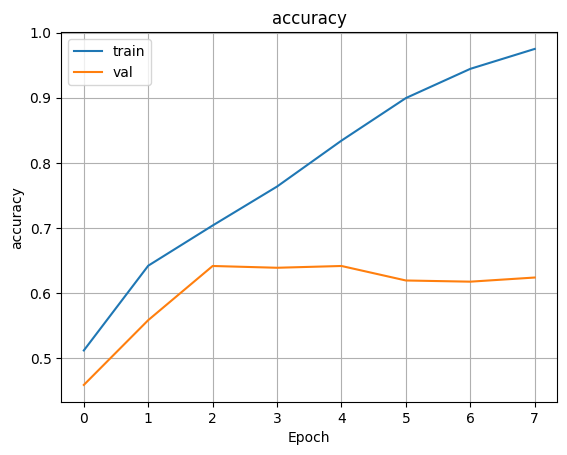

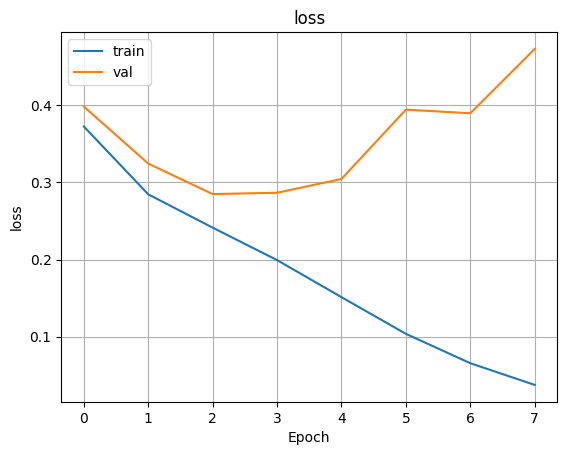

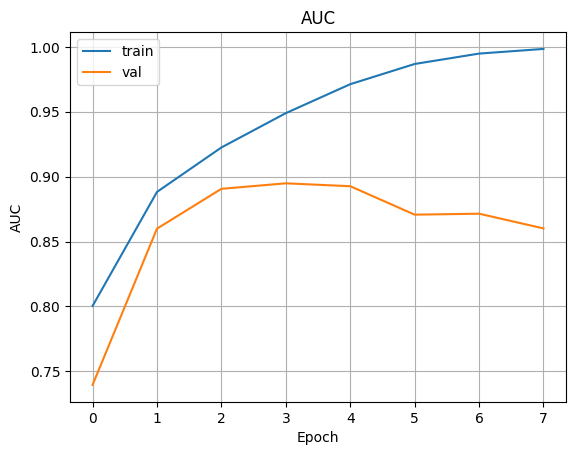

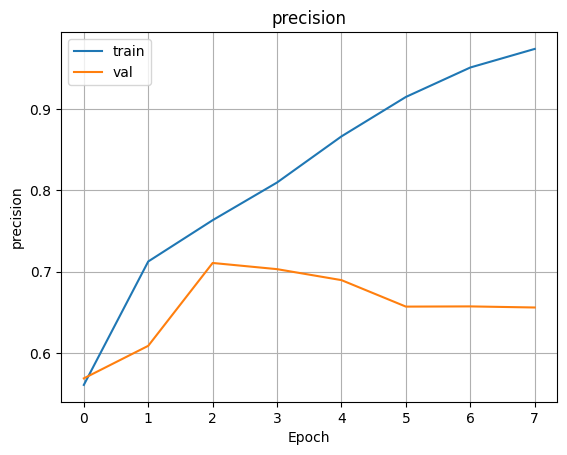

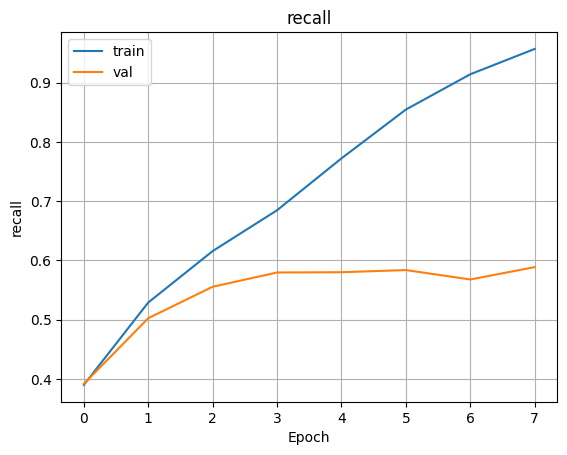

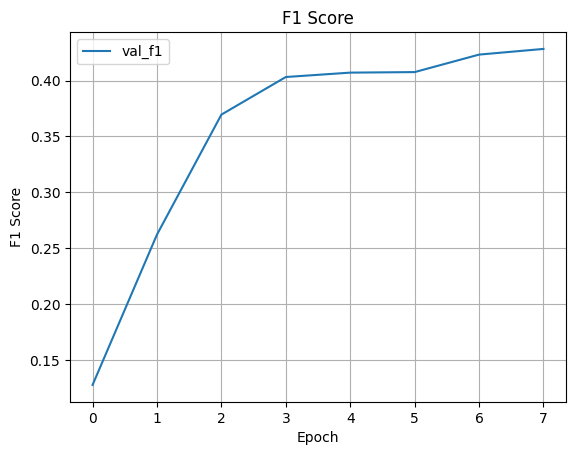

In [43]:
def plot_metrics(history, f1_scores):
    metrics = ['accuracy', 'loss', 'AUC', 'precision', 'recall']
    for m in metrics:
        plt.figure()
        plt.plot(history.history[m], label='train')
        plt.plot(history.history['val_' + m], label='val')
        plt.title(m)
        plt.xlabel('Epoch')
        plt.ylabel(m)
        plt.legend()
        plt.grid(True)
        plt.show()

    # F1 score plot
    plt.figure()
    plt.plot(f1_scores, label='val_f1')
    plt.title('F1 Score')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_metrics(history, f1_callback.f1_scores)


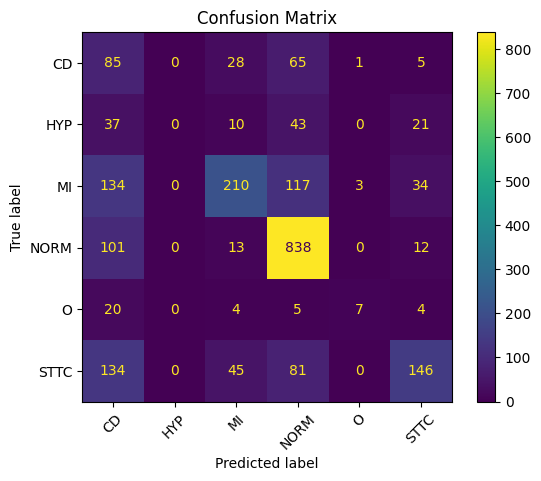

In [44]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict probabilities
pred = model.predict(X_test, verbose=0)

# Convert probabilities to binary labels
pred_bin = (pred > 0.5).astype(int)

# Convert one-hot to class index for confusion matrix
y_true_cls = np.argmax(y_test_bin, axis=1)
y_pred_cls = np.argmax(pred_bin, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true_cls, y_pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mlb.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


In [45]:
model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 64)        │  6,171,584 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_10       │ (None, 64)        │     93,760 │ input_layer[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_11       │ (None, 64)        │    199,872 │ input_layer[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 192)       │          0 │ sequential[0][0], │
│ (Concatenate)       │                   │            │ functional_10[0]… │
│                     │                   │            │ functional_11[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     24,704 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 6)         │        774 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,470,676 (74.27 MB)

 Trainable params: 6,489,990 (24.76 MB)

 Non-trainable params: 704 (2.75 KB)

 Optimizer params: 12,979,982 (49.51 MB)